In [1]:
#%pylab nbaggpython
%matplotlib inline
#%matplotlib widget
import numpy as np
import glob
import os.path
import matplotlib.pyplot as plt 
from scipy import stats

import sys  
# sys.path.insert(0, '/Users/giovanni/Documents/GitHub/fufo/notebooks/')
# from functions import AAL_Atlas_ORDER2021_n as AAL
# from functions import AAL_Atlas_ordclu as aal

#from scipy.integrate import simps
def model_func_lin(x, a, b):
    return a * x**8 + b
from numpy import trapz
from scipy.optimize import curve_fit

import pandas as pd
import ptitprince as pt
import itertools
import seaborn as sns

sys.path.insert(0, '/Users/giovanni/Documents/GitHub/fufo/')
from src import analysis, simulation  # Import analysis for fcd and clustering

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/tvb/datatypes/surfaces.py:61: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


In [2]:
import csv
path_abh='/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'

In [3]:
import pickle

def save_obj(obj, name ):
    with open(path_abh+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name ):
    with open(path_abh+ name + '.pkl', 'rb') as f:
        return pickle.load(f)

# FIG2

In [4]:
# Carmela

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       'E': 0., #check
       
       ## Time costants
       'Cm': 1,#10, #1
       'tau_n': 4,#2.5,#4 
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

In [5]:
beta= Par['w_i'] / Par['w_o']

In [6]:
min_2_sim=1/3
Np= int(min_2_sim*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*10)
Single_Carmela=load_obj('Single_Carmela')
K_bath_vec=Single_Carmela.keys()

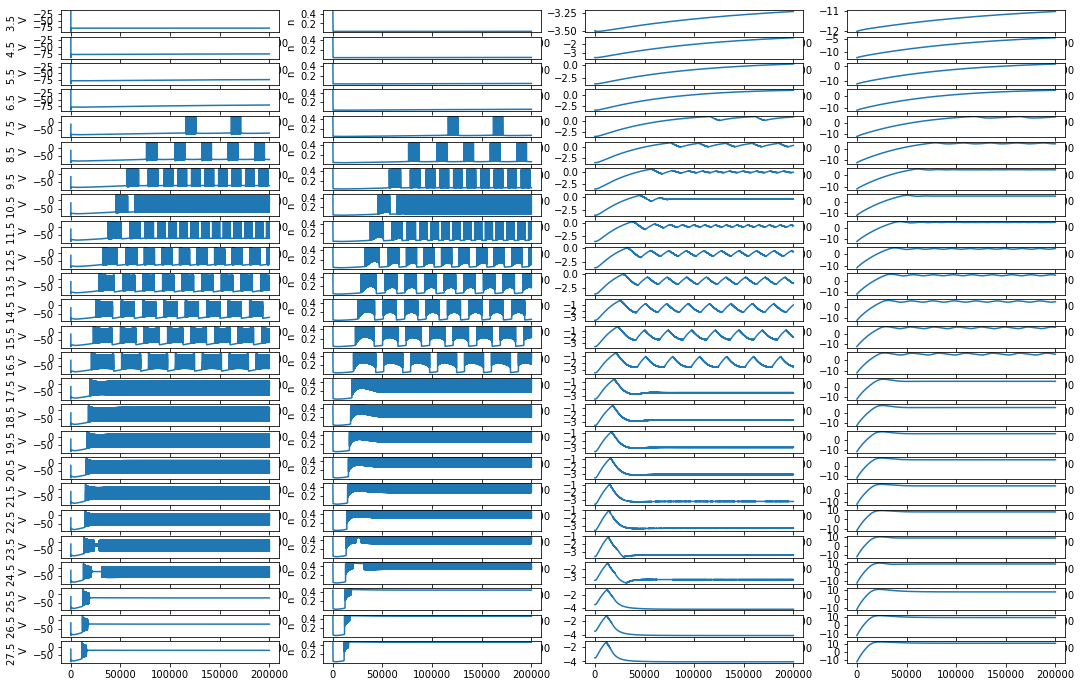

In [9]:
fig, axs = plt.subplots(len(K_bath_vec), 4, figsize=(18,12))
for ik, k in enumerate(K_bath_vec):
    axs[ik,0].plot(Single_Carmela[k]['V']);axs[ik,0].set_ylabel('%.1f \n V'%k)
    axs[ik,1].plot(Single_Carmela[k]['n']);axs[ik,1].set_ylabel('n')
    axs[ik,2].plot(Single_Carmela[k]['DK_i']);
    axs[ik,3].plot(Single_Carmela[k]['Kg']);
plt.show()

# Panel a

### Bursting

In [7]:
k=7.5 

In [126]:
# 10 Seconds activity
V=Single_Carmela[k]['V'][::10][10000:] 
beta= Par['w_i'] / Par['w_o']
K = Par['K_o0'] + -beta * Single_Carmela[k]['DK_i'][::10][10000:] + Single_Carmela[k]['Kg'][::10][10000:]

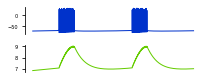

In [135]:
fig = plt.figure(figsize=(3,1.2))
ax1 = fig.add_subplot(211)
ax1.plot(V,c='#0032cb',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

ax1 = fig.add_subplot(212)
ax1.plot(K,c='#65cc00',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

plt.tight_layout()
plt.savefig(path_abh+'Figures/Fig2/VK75.pdf')
plt.show()

### Tonic Spiking

In [136]:
k=10.5

In [137]:
# 1 Seconds activity
V=Single_Carmela[k]['V'][:][190000:]
K = Par['K_o0'] + -beta * Single_Carmela[k]['DK_i'][:][190000:] + Single_Carmela[k]['Kg'][:][190000:]

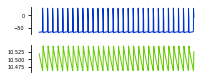

In [138]:
fig = plt.figure(figsize=(3,1.2))
ax1 = fig.add_subplot(211)
ax1.plot(V,c='#0032cb',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

ax1 = fig.add_subplot(212)
ax1.plot(K,c='#65cc00',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

plt.tight_layout()
plt.savefig(path_abh+'Figures/Fig2/VK105.pdf')
plt.show()

### Seizure-like events

In [139]:
k=15.5

In [140]:
# 10 Seconds activity
V=Single_Carmela[k]['V'][::10][-10500:-1500]
K = Par['K_o0'] + -beta * Single_Carmela[k]['DK_i'][::10][-10500:-1500] + Single_Carmela[k]['Kg'][::10][-10500:-1500]

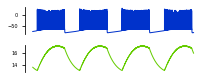

In [141]:
fig = plt.figure(figsize=(3,1.2))
ax1 = fig.add_subplot(211)
ax1.plot(V,c='#0032cb',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

ax1 = fig.add_subplot(212)
ax1.plot(K,c='#65cc00',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

plt.tight_layout()
plt.savefig(path_abh+'Figures/Fig2/VK155.pdf')
plt.show()

### Sustained ictal activity

In [142]:
k=24.5

In [143]:
# 10 Seconds activity
V=Single_Carmela[k]['V'][::10][:10000]
K = Par['K_o0'] + -beta * Single_Carmela[k]['DK_i'][::10][:10000] + Single_Carmela[k]['Kg'][::10][:10000]

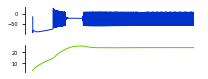

In [145]:
fig = plt.figure(figsize=(3,1.2))
ax1 = fig.add_subplot(211)
ax1.plot(V,c='#0032cb',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

ax1 = fig.add_subplot(212)
ax1.plot(K,c='#65cc00',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

plt.tight_layout()
plt.savefig(path_abh+'Figures/Fig2/VK245.pdf')
plt.show()

### Depolarization Block

In [146]:
k=27.5

In [147]:
# 10 Seconds activity
V=Single_Carmela[k]['V'][::10][:10000]
K = Par['K_o0'] + -beta * Single_Carmela[k]['DK_i'][::10][:10000] + Single_Carmela[k]['Kg'][::10][:10000]

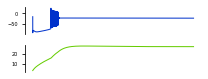

In [148]:
fig = plt.figure(figsize=(3,1.2))
ax1 = fig.add_subplot(211)
ax1.plot(V,c='#0032cb',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

ax1 = fig.add_subplot(212)
ax1.plot(K,c='#65cc00',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)

plt.tight_layout()
plt.savefig(path_abh+'Figures/Fig2/VK275.pdf')
plt.show()

# Panel b

In [7]:
k=15.5

In [8]:
x=Single_Carmela[k]['V'][-105000:-80000]
y=Single_Carmela[k]['n'][-105000:-80000]
z =Par['K_o0'] + -beta * Single_Carmela[k]['DK_i'][-105000:-80000] + Single_Carmela[k]['Kg'][-105000:-80000]

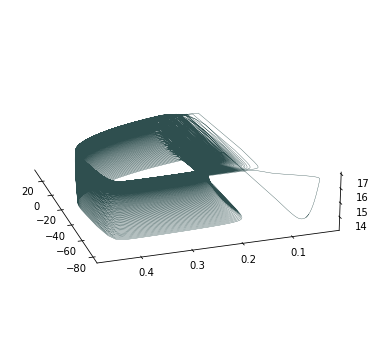

In [17]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
  
fig = plt.figure(figsize=plt.figaspect(0.5)*1.25)

ax = plt.axes(projection = '3d')
  
ax.plot3D(x, y, z, 'darkslategray', linewidth=0.35)
  
ax.view_init(22, -198)
ax.set_box_aspect(aspect = (1,1,0.25))
ax.set_zticks([14,15,16,17])

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)

#ax.set_axis_off()

plt.tight_layout()  
plt.savefig(path_abh+'Figures/Fig2/3d.png', dpi=300)
plt.show()

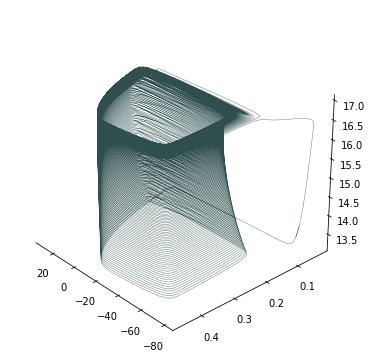

In [116]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
  
fig = plt.figure(figsize=plt.figaspect(0.5)*1.25)

ax = plt.axes(projection = '3d')
  
ax.plot3D(x, y, z, 'darkslategray', linewidth=0.35)
  
ax.view_init(30, -222)
ax.set_box_aspect(aspect = (1,1,0.85))

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)

#ax.set_axis_off()

plt.tight_layout()  
plt.savefig(path_abh+'Figures/Fig2/3d.png', dpi=300)
plt.show()

# Figure 4

In [8]:
# Carmela

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       'E': 0., #check
       
       ## Time costants
       'Cm': 1,#10, #1
       'tau_n': 4,#2.5,#4 
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

In [13]:
import pickle5 as pickle
with open('/Users/giovanni/Documents/GitHub/fufo/notebook/Abhirup/Carmela/Results_J_1_over_N.pkl', 'rb') as f:
    Population = pickle.load(f)

In [14]:
Population[kb]['Population'].keys()

NameError: name 'kb' is not defined

In [12]:
with open('/Users/giovanni/Documents/GitHub/fufo/notebook/Abhirup/Carmela/Results_J_0.1_over_N.pkl', 'rb') as f:
    Population01 = pickle.load(f)

ValueError: unsupported pickle protocol: 5

In [416]:
Population01[kb]['Population'].keys()

dict_keys(['K_bath', 'x', 'V', 'n', 'DK_i', 'Kg'])

In [44]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 12)
print(viridis)

In [76]:
colpop=viridis(3)#'tomato'
colmf=viridis(6)#'#0032cb'
xsiz=1.6+0.14
ysiz=0.8
ks=0.14

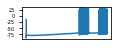

In [287]:
# plt.figure(figsize=(xsiz,ysiz))
# plt.plot(V[:10000])
# plt.yticks([-75,-50,-25,0,25],['-75','-50','-25','0','25'],fontsize=5)
# plt.xticks([])
# plt.tight_layout()
# plt.savefig('labels.pdf')
# plt.show()

In [114]:

kb=7.5
beta= Par['w_i'] / Par['w_o'] 
V_pop= Population[kb]['Population']['V']
V=Population[kb]['Mean_field']['V']
DKi_pop=Population[kb]['Population']['DK_i']
Kg_pop=Population[kb]['Population']['Kg']
DKi=Population[kb]['Mean_field']['DK_i']
Kg=Population[kb]['Mean_field']['Kg']
Kext_pop = Par['K_o0'] + -beta *DKi_pop + Kg_pop
Kext = Par['K_o0'] + -beta * DKi + Kg

In [115]:
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
#ax.spines["bottom"].set_visible(False)
#ax.legend(handlelength=1,fontsize=9,frameon=False,loc='upper right', bbox_to_anchor=(1.2, ysiz))
#ax.tick_params(axis='both',labelsize=5)

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


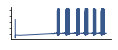

In [116]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V_pop,c=colpop,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('VPop75.pdf',dpi=300)
plt.show()

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


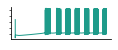

In [117]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('V75.pdf',dpi=300)
plt.show()

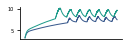

In [120]:
fig, ax = plt.subplots(figsize=(xsiz+0.15,ysiz))
ax.plot(Kext_pop,c=colpop,linewidth=1)
ax.plot(Kext,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([5,10])
ax.tick_params(axis='both',labelsize=5)
plt.tight_layout()
plt.savefig('K75.pdf',dpi=300)
plt.show()

In [96]:
np.max(Kext_pop)

8.384711818951597

In [121]:
kb=11.5
beta= Par['w_i'] / Par['w_o'] 
V_pop= Population[kb]['Population']['V']
V=Population[kb]['Mean_field']['V']
DKi_pop=Population[kb]['Population']['DK_i']
Kg_pop=Population[kb]['Population']['Kg']
DKi=Population[kb]['Mean_field']['DK_i']
Kg=Population[kb]['Mean_field']['Kg']
Kext_pop = Par['K_o0'] + -beta *DKi_pop + Kg_pop
Kext = Par['K_o0'] + -beta * DKi + Kg

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


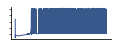

In [122]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V_pop,c=colpop,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('VPop115.pdf',dpi=300)
plt.show()

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


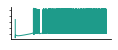

In [123]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('V115.pdf',dpi=300)
plt.show()

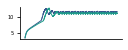

In [124]:
fig, ax = plt.subplots(figsize=(xsiz+0.15,ysiz))
ax.plot(Kext_pop,c=colpop,linewidth=1)
ax.plot(Kext,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([5,10])
ax.tick_params(axis='both',labelsize=5)
plt.tight_layout()
plt.savefig('K115.pdf',dpi=300)
plt.show()

In [125]:
kb=15.5
beta= Par['w_i'] / Par['w_o'] 
V_pop= Population[kb]['Population']['V']
V=Population[kb]['Mean_field']['V']
DKi_pop=Population[kb]['Population']['DK_i']
Kg_pop=Population[kb]['Population']['Kg']
DKi=Population[kb]['Mean_field']['DK_i']
Kg=Population[kb]['Mean_field']['Kg']
Kext_pop = Par['K_o0'] + -beta *DKi_pop + Kg_pop
Kext = Par['K_o0'] + -beta * DKi + Kg

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


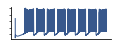

In [126]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V_pop,c=colpop,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('VPop155.pdf',dpi=300)
plt.show()

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


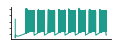

In [127]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('V155.pdf',dpi=300)
plt.show()

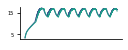

In [128]:
fig, ax = plt.subplots(figsize=(xsiz+0.15,ysiz))
ax.plot(Kext_pop,c=colpop,linewidth=1)
ax.plot(Kext,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([5,15])
ax.tick_params(axis='both',labelsize=5)
plt.tight_layout()
plt.savefig('K155.pdf',dpi=300)
plt.show()

In [129]:
kb=21.5
beta= Par['w_i'] / Par['w_o'] 
V_pop= Population[kb]['Population']['V']
V=Population[kb]['Mean_field']['V']
DKi_pop=Population[kb]['Population']['DK_i']
Kg_pop=Population[kb]['Population']['Kg']
DKi=Population[kb]['Mean_field']['DK_i']
Kg=Population[kb]['Mean_field']['Kg']
Kext_pop = Par['K_o0'] + -beta *DKi_pop + Kg_pop
Kext = Par['K_o0'] + -beta * DKi + Kg

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


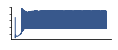

In [130]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V_pop,c=colpop,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('VPop215.pdf',dpi=300)
plt.show()

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


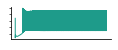

In [131]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('V215.pdf',dpi=300)
plt.show()

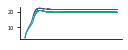

In [132]:
fig, ax = plt.subplots(figsize=(xsiz+0.15,ysiz))
ax.plot(Kext_pop,c=colpop,linewidth=1)
ax.plot(Kext,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([10,20])
ax.tick_params(axis='both',labelsize=5)
plt.tight_layout()
plt.savefig('K215.pdf',dpi=300)
plt.show()

In [133]:
kb=27.5
beta= Par['w_i'] / Par['w_o'] 
V_pop= Population[kb]['Population']['V']
V=Population[kb]['Mean_field']['V']
DKi_pop=Population[kb]['Population']['DK_i']
Kg_pop=Population[kb]['Population']['Kg']
DKi=Population[kb]['Mean_field']['DK_i']
Kg=Population[kb]['Mean_field']['Kg']
Kext_pop = Par['K_o0'] + -beta *DKi_pop + Kg_pop
Kext = Par['K_o0'] + -beta * DKi + Kg

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


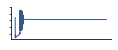

In [134]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V_pop,c=colpop,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('VPop275.pdf',dpi=300)
plt.show()

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  import sys


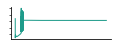

In [136]:
fig, ax = plt.subplots(figsize=(xsiz,ysiz))
ax.plot(V,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([-75,-50,-25,0,25],['','','','',''])
plt.tight_layout()
plt.savefig('V275.pdf',dpi=300)
plt.show()

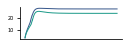

In [137]:
fig, ax = plt.subplots(figsize=(xsiz+0.15,ysiz))
ax.plot(Kext_pop,c=colpop,linewidth=1)
ax.plot(Kext,c=colmf,linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([10,20])
ax.tick_params(axis='both',labelsize=5)
plt.tight_layout()
plt.savefig('K275.pdf',dpi=300)
plt.show()

In [345]:
Population[3.5]['Mean_field']['K_bath_approx']

3.5

In [347]:
Kb=[]
Kb_eff=[]
for i in Population.keys():
    Kb.append(i)
    Kb_eff.append(Population[i]['Mean_field']['K_bath_approx'])

In [417]:
Kb01=[]
Kb_eff01=[]
for i in Population01.keys():
    Kb01.append(i)
    Kb_eff01.append(Population01[i]['Mean_field']['K_bath_approx'])

In [414]:
Kb

[3.5, 5.5, 7.5, 9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5, 25.5, 27.5]

In [413]:
Kb_eff

[3.5, 5.5, 8.9, 9.6, 11.1, 13.5, 15.1, 17.5, 19.5, 19.7, 19.7, 22.5, 23.8]

In [2]:
Kb=np.asarray([7.5, 11.5, 15.5, 21.5, 27.5])
Kb_eff=np.asarray([8.9, 11.1, 15.1, 19.7,23.8])

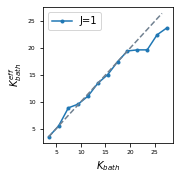

In [348]:
plt.figure(figsize=(2.6,2.6))
plt.plot(Kb,Kb_eff,'.-',label='J=1')
plt.plot(np.arange(3.5,27.5),np.arange(3.5,27.5),'--',c='slategray')
plt.xlabel('$K_{bath}$');plt.xticks([5,10,15,20,25],fontsize=6)
plt.ylabel('$K_{bath}^{eff}$');plt.yticks([5,10,15,20,25],fontsize=6)
plt.legend()
plt.tight_layout()
plt.savefig('KeffJ1.pdf')
plt.show()

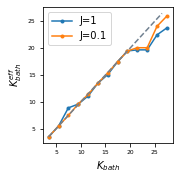

In [419]:
plt.figure(figsize=(2.6,2.6))
plt.plot(Kb,Kb_eff,'.-',label='J=1')
plt.plot(Kb01,Kb_eff01,'.-',label='J=0.1')
plt.plot(np.arange(3.5,27.5),np.arange(3.5,27.5),'--',c='slategray')
plt.xlabel('$K_{bath}$');plt.xticks([5,10,15,20,25],fontsize=6)
plt.ylabel('$K_{bath}^{eff}$');plt.yticks([5,10,15,20,25],fontsize=6)
plt.legend()
plt.tight_layout()
plt.savefig('KeffJ1.pdf')
plt.show()

In [3]:
Kb=np.asarray([3.5, 5.5, 7.5, 9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5, 25.5, 27.5])
Kb_eff=np.asarray([3.5, 5.5, 8.9, 9.6, 11.1, 13.5, 15.1, 17.5, 19.5, 19.7, 19.7, 22.5, 23.8])

In [39]:
Kb01=np.asarray([3.5, 5.5, 7.5, 9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5, 25.5, 27.5])
Kb_eff01=np.asarray([3.5, 5.5, 7.4, 9.6, 11.1, 13.5, 15.3, 17.5, 19.7, 20.1, 20.08, 24., 25.8])

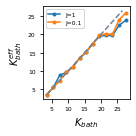

In [45]:
plt.figure(figsize=(2.,2))
plt.plot(Kb,Kb_eff,'.-',label='J=1')
plt.plot(Kb01,Kb_eff01,'.-',label='J=0.1')
plt.plot(np.arange(3.5,27.5),np.arange(3.5,27.5),'--',c='slategray')
plt.xlabel('$K_{bath}$');plt.xticks([5,10,15,20,25],fontsize=6)
plt.ylabel('$K_{bath}^{eff}$');plt.yticks([5,10,15,20,25],fontsize=6)
plt.legend(fontsize=6)
plt.tight_layout()
plt.savefig('KeffJ1x.pdf')
plt.show()

In [8]:
path_abh

'/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'

In [259]:
mydata.shape

(201, 300)

In [70]:
mydata_cm = genfromtxt(path_abh+'C-_Values.csv', delimiter=',')

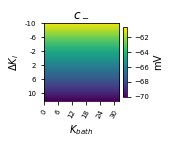

In [71]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$c_-$',fontsize=12)
plt.imshow(mydata_cm,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
#plt.savefig('Cmin.pdf') 
plt.show()

In [72]:
mydata_cp = genfromtxt(path_abh+'C+_Values.csv', delimiter=',')

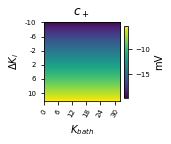

In [73]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.5,2.1))
plt.title('$c_+$',fontsize=12)
plt.imshow(mydata_cp,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.91)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
plt.savefig('Cplus.pdf') 
plt.show()

In [74]:
mydata_im = genfromtxt(path_abh+'I-_Values.csv', delimiter=',')

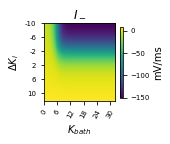

In [75]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$I_-$',fontsize=12)
plt.imshow(mydata_im,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.91)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV/ms',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
#plt.savefig('Imin.pdf') 
plt.show()

In [76]:
mydata_ip = genfromtxt(path_abh+'I+_Values.csv', delimiter=',')

In [49]:
mydata_ip.shape

(201, 300)

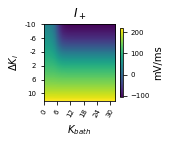

In [77]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$I_+$',fontsize=12)
plt.imshow(mydata_ip,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV/ms',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
#plt.savefig('Iplus.pdf') 
plt.show()

# Vth

In [253]:
vthmask=np.zeros((201,300))
for i in range(300):
    vthmask[np.argmin(np.abs(mydata_im[:,i])),i]=1

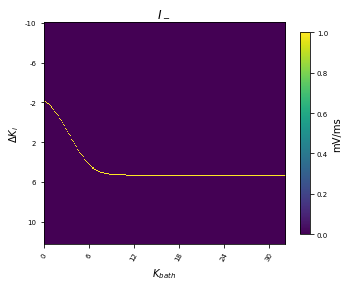

In [254]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(5,4.1))
plt.title('$I_-$',fontsize=12)
plt.imshow(vthmask,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.91)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV/ms',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
#plt.savefig('Imin.pdf') 
plt.show()

In [255]:
vth=np.zeros((300))
for i in range(300):
    vth[i]=mydata_cm[np.where(vthmask[:,i]==1)[0],i]

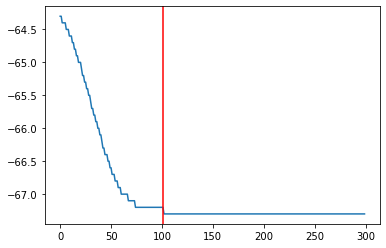

In [256]:
plt.plot(vth)
plt.axvline(101,c='r')

In [19]:
vth

array([-64.3, -64.3, -64.4, -64.4, -64.4, -64.4, -64.5, -64.5, -64.5,
       -64.6, -64.6, -64.6, -64.7, -64.7, -64.8, -64.8, -64.9, -64.9,
       -65. , -65. , -65. , -65.1, -65.2, -65.2, -65.3, -65.3, -65.4,
       -65.4, -65.5, -65.5, -65.6, -65.7, -65.7, -65.8, -65.8, -65.9,
       -65.9, -66. , -66. , -66.1, -66.1, -66.2, -66.3, -66.3, -66.4,
       -66.4, -66.4, -66.5, -66.5, -66.6, -66.6, -66.7, -66.7, -66.7,
       -66.8, -66.8, -66.8, -66.9, -66.9, -66.9, -67. , -67. , -67. ,
       -67. , -67. , -67. , -67. , -67.1, -67.1, -67.1, -67.1, -67.1,
       -67.1, -67.1, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2,
       -67.2, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2,
       -67.2, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2, -67.2,
       -67.2, -67.2, -67.2, -67.3, -67.3, -67.3, -67.3, -67.3, -67.3,
       -67.3, -67.3, -67.3, -67.3, -67.3, -67.3, -67.3, -67.3, -67.3,
       -67.3, -67.3, -67.3, -67.3, -67.3, -67.3, -67.3, -67.3, -67.3,
       -67.3, -67.3,

In [16]:
np.abs(mydata).min()

0.000324514399970166

# Vstar

In [1592]:
w_i     = 2800.0
w_o     = 500 #720.0
beta    = w_i/w_o

In [1593]:
Na0o=138.0
Na0i=18.0
DKi=10

In [1594]:
V=np.arange(-80,-25,0.01)

In [1595]:
line=V-26.64*np.log((Na0o+beta*DKi)/(Na0i-DKi))
hype=30.*(1.+np.exp((-22.-V)/15))/(1.-np.exp((-22.-V)/15))

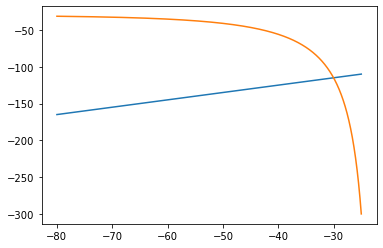

In [1596]:
plt.plot(V,line)
plt.plot(V,hype)

In [1597]:
w_i     = 2800.0
w_o     = 500 #720.0
beta    = w_i/w_o
Na0o=138.0
Na0i=18.0
V=np.arange(-80,-25,0.01)

Vth=np.zeros(200)
for ii, i in enumerate(np.arange(-10,10,0.1)):
    line=V-26.64*np.log((Na0o+beta*i)/(Na0i-i))
    hype=30.*(1.+np.exp((-22.-V)/15))/(1.-np.exp((-22.-V)/15))
    Vth[ii]=V[np.argsort(np.abs(line-hype))[0]]

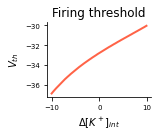

In [1598]:
fig, ax = plt.subplots(figsize=(2.3,2))
ax.set_title('Firing threshold')
ax.plot(np.arange(-10,10,0.1),Vth,c='tomato',linewidth=2)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='both',labelsize=7)
ax.set_xlabel('$\Delta [K^+]_{int}$')
ax.set_ylabel('$V_{th}$')
#ax.set_yticks([])
plt.tight_layout()
plt.savefig('Vth.pdf')
plt.show()

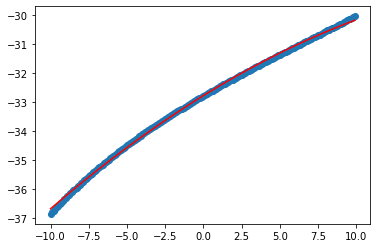

In [1599]:
#polynomial fit with degree = 2
model = np.poly1d(np.polyfit(np.arange(-10,10,0.1), Vth, 2))

#add fitted polynomial line to scatterplot
plt.scatter(np.arange(-10,10,0.1), Vth)
plt.plot(np.arange(-10,10,0.1), model(np.arange(-10,10,0.1)),c='r')
plt.show()

In [1600]:
print(model)

           2
-0.006436 x + 0.3258 x - 32.77


In [1601]:
#define function to calculate r-squared
def polyfit(x, y, degree):
    results = {}
    coeffs = np.polyfit(x, y, degree)
    p = np.poly1d(coeffs)
    #calculate r-squared
    yhat = p(x)
    ybar = np.sum(y)/len(y)
    ssreg = np.sum((yhat-ybar)**2)
    sstot = np.sum((y - ybar)**2)
    results['r_squared'] = ssreg / sstot

    return results

#find r-squared of polynomial model with degree = 3
polyfit(np.arange(-10,10,0.1), Vth, 2)

#{'r_squared': 0.9092114182131691}

{'r_squared': 0.9990438484771268}

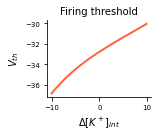

In [1602]:
fig, ax = plt.subplots(figsize=(2.3,2))
ax.set_title('Firing threshold',fontsize=10)
ax.plot(np.arange(-10,10,0.1),Vth,c='tomato',linewidth=2)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='both',labelsize=7)
ax.set_xlabel('$\Delta [K^+]_{int}$')
ax.set_ylabel('$V_{th}$')
#ax.set_yticks([])
plt.tight_layout()
plt.savefig('Vth.pdf')
plt.show()

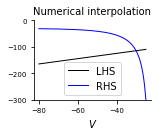

In [1606]:
fig, ax = plt.subplots(figsize=(2.3,2))
ax.set_title('Numerical interpolation',fontsize=10)
ax.plot(V,line,c='k',linewidth=1,label='LHS')
ax.plot(V,hype,c='blue',linewidth=1,label='RHS')
#ax.hlines(0,0,105,color='k',linewidth=0.5)
ax.set_ylim(-300,0)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='both',labelsize=7)
ax.set_xlabel('$V$')
#ax.set_yticks([])
plt.tight_layout()
plt.savefig('interp.pdf')
plt.show()

In [1672]:
a=16.

In [1712]:
V=np.arange(-80,0.,0.01)
la=(1/np.pi)*(a/((V+55.)**2+(a)**2))

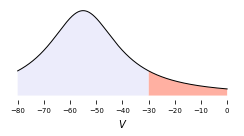

In [1713]:
f, ax = plt.subplots(figsize=(3.5, 2.))
pts=5000
plt.plot(V, 10*la,c='k',linewidth=1,label='original')
plt.fill_between(V[pts:], 10*la[pts:], facecolor='tomato', alpha=0.5)
plt.fill_between(V[:pts], 10*la[:pts], facecolor='lavender', alpha=0.75)
ax.set_frame_on(False)
ax.tick_params(axis='both',labelsize=7)
plt.yticks([])

ax.set_xlabel('$V$')
#plt.legend();
plt.tight_layout()
plt.savefig('LA.pdf', transparent=True, format="PDF")
plt.show()

In [243]:
mydata = genfromtxt(path_abh+'VDot_vs_V_forall_DelKi_125.csv', delimiter=',')

In [244]:
mydata.shape

(2001, 201)

In [245]:
V=np.linspace(-80,0,1200)

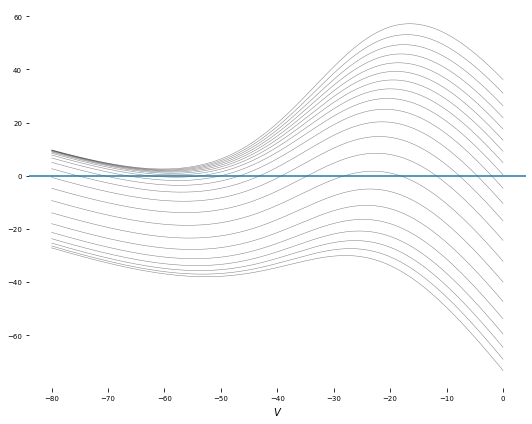

In [252]:
f, ax = plt.subplots(figsize=(7.5, 6.))
plt.plot(V,mydata[:1200,::10],c='k',linewidth=0.5,alpha=0.5,label='original')
#plt.plot(V,mydata[:1200,:],c='k',linewidth=0.5,alpha=1.,label='original')
#plt.fill_between(V[4500:], mydata[:,0], facecolor='tomato', alpha=0.75)
plt.axhline(0)
ax.set_frame_on(False)
ax.tick_params(axis='both',labelsize=7)
#plt.yticks([])

ax.set_xlabel('$V$')
#ax.set_ylabel('$\mathrm{d}V/\mathrm{d}t}$')
#plt.legend();
plt.tight_layout()
#plt.savefig('vdot.pdf', transparent=True, format="PDF")
plt.show()

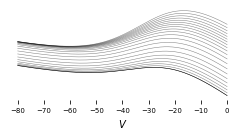

In [1716]:
f, ax = plt.subplots(figsize=(3.5, 2.))
plt.plot(V,mydata[:1200,::10],c='k',linewidth=0.5,alpha=0.5,label='original')
plt.plot(V,mydata[:1200,:],c='k',linewidth=0.5,alpha=1.,label='original')
#plt.fill_between(V[4500:], mydata[:,0], facecolor='tomato', alpha=0.75)
ax.set_frame_on(False)
ax.tick_params(axis='both',labelsize=7)
plt.yticks([])

ax.set_xlabel('$V$')
#ax.set_ylabel('$\mathrm{d}V/\mathrm{d}t}$')
#plt.legend();
plt.tight_layout()
#plt.savefig('vdot.pdf', transparent=True, format="PDF")
plt.show()

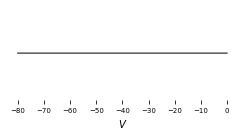

In [1710]:
f, ax = plt.subplots(figsize=(3.5, 2.))
plt.plot(V, np.zeros(len(V)),c='k',linewidth=1,label='original')

ax.set_frame_on(False)
ax.tick_params(axis='both',labelsize=7)
plt.yticks([])

ax.set_xlabel('$V$')
#plt.legend();
plt.tight_layout()
plt.savefig('L0.pdf', transparent=True, format="PDF")
plt.show()

In [596]:
Ki=np.arange(-10,10,0.1)

In [597]:
Kb=np.arange(0,30,0.1)

In [802]:
def fun(ki,kb,a,b,c,d,e,f,g):
    return (1+ 1*ki)*np.heaviside(ki,0) -40/((1+np.exp(6-kb))*(1+np.exp(1*ki+3)))*np.heaviside(-ki,0)

In [843]:
show=np.zeros((len(Ki),len(Kb)))
for ii, i in enumerate(Ki):
    for ib, b in enumerate(Kb):
        show[ii,ib]=fun(i,b,1,3,-35,-1,6,1,3)

In [1415]:
def fun(ki,kb,a,b,c,d,e,f,g,h):
    return (a+ b*ki)*np.heaviside(ki,0) +(c/((1+np.exp(d*kb+e))*(1+np.exp(f*ki+g)))+h)*np.heaviside(-ki,0)

In [1416]:
show=np.zeros((len(Ki),len(Kb)))
for ii, i in enumerate(Ki):
    for ib, b in enumerate(Kb):
        show[ii,ib]=fun(i,b, 16.,    3.9,   -50.,    -1., 5.       ,    0.8        , 3.,   17)# 22.5,    3.4,   -54.,    -1., 5.4       ,    0.8        , 3,   24)

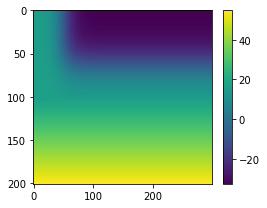

In [1417]:
plt.figure(figsize=(4,3.2))
plt.imshow(show,aspect='auto')
plt.colorbar()

In [1571]:
def fun(ki,kb,a,b,c,d,e,f,g):
    return (a+ b*ki) +c/((1+np.exp(d*kb+e))*(1+np.exp(f*ki+g)))

In [1586]:
show=np.zeros((len(Ki),len(Kb)))
for ii, i in enumerate(Ki):
    for ib, b in enumerate(Kb):
        show[ii,ib]=fun(i,b, 22.,    3.8,   -36.,    -1., 5.6       ,    0.8        , 2.)# 22.5,    3.4,   -54.,    -1., 5.4       ,    0.8        , 3,   24)

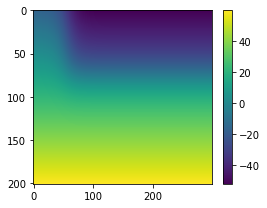

In [1587]:
plt.figure(figsize=(4,3.2))
plt.imshow(show,aspect='auto')
plt.colorbar()

In [1588]:
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(show.flatten(), mydata.flatten())
r_value**2

0.9952357121230675

In [1121]:
import scipy

In [897]:
from scipy.optimize import curve_fit

In [898]:
Ki=np.arange(-10,10.1,0.1)

In [899]:
Kb=np.arange(0.,30,0.1)

In [900]:
mydata = genfromtxt(path_abh+'I+_Matrix.csv', delimiter=',')

In [935]:
def func(x,a,b,c,d,e,f,g,h,i):
    return (a+ b*x[0])*np.heaviside(x[0],i) +(c/((1+np.exp(x[1]+e))*(1+np.exp(x[0]+g)))+h)*np.heaviside(-x[0],i)

In [1399]:
def func(x,a,b,c,d,e,f,g,h,i):
    return (a+ b*x[0])/(1+np.exp(c*x[0])) +(d/((1+np.exp(e*x[1]+f))*(1+np.exp(g*x[0]+h)))+i)/(1+np.exp(-c*x[0]))

In [1589]:
def func(x,a,b,c,d,e,f,g):
    return (a+ b*x[0]) +c/((1+np.exp(d*x[1]+e))*(1+np.exp(f*x[0]+g)))

In [1590]:
z_vec = mydata.flatten()
x_data = np.array([
    (Ki[i // mydata.shape[1]], Kb[i % mydata.shape[1]]) 
    for i in range(len(z_vec))
]).T

assert x_data.shape[1] == len(z_vec)
assert x_data.shape[0] == 2

curve_fit(func, x_data, z_vec)

/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: overflow encountered in exp
  
/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: overflow encountered in multiply
  
/Users/giovanni/anaconda2/envs/p36workshop/lib/python3.6/site-packages/scipy/optimize/minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


(array([  13.7361667 ,    4.26707288,    3.98387402,  -93.77140052,
         -39.65693322,   -9.29934643, -208.06279552]),
 array([[inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf]]))

2

In [890]:
(len(z_vec) == x_data.shape[1])

True

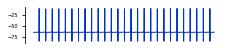

In [22]:
fig, ax = plt.subplots(figsize=(3.3,0.8))
ax.plot(V[0:600000],c='#0032cb',linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
#ax.legend(handlelength=1,fontsize=9,frameon=False,loc='upper right', bbox_to_anchor=(1.2, 0.8))
ax.tick_params(axis='both',labelsize=5)
plt.tight_layout()
#plt.savefig('V12.pdf')
plt.show()

In [297]:
x = y = np.arange(-2., 2., 0.01)
X, Y = np.meshgrid(x, y)
z=stats.multivariate_normal([0, 0],[0.2,1]).pdf(np.dstack((X, Y)))

In [299]:
z.shape

(400, 400)

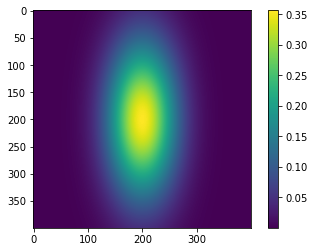

In [300]:
plt.imshow(z)
plt.colorbar()

In [272]:
from matplotlib import  mlab

In [273]:
from scipy import stats

In [288]:

for i in range(4):
    mu_x= np.random.rand()-np.random.rand()
    mu_y= np.random.rand()-np.random.rand()
    sig_x= np.random.rand()
    sig_y= np.random.rand()
    rv = stats.multivariate_normal([mu_x, mu_y],[sig_x, sig_y])
    Z = rv.pdf(np.dstack((X, Y)))

In [306]:
3/0.01

300.0

In [2]:
def get_test_data(delta=0.025):

    x = y = np.arange(-8, 8, delta)
    X, Y = np.meshgrid(x, y)
    siz=int(16/0.025)
    Z=np.zeros((siz,siz))
    
    for i in range(4):
        mu_x= 10*(np.random.rand()-np.random.rand())
        mu_y= 10*(np.random.rand()-np.random.rand())
        sig_x= 0.7-(i/7)#np.random.rand()
        sig_y= 0.6-(i/7) #np.random.rand()
        rv = stats.multivariate_normal([mu_x, mu_y],[sig_x, sig_y])
        Z -= rv.pdf(np.dstack((X, Y)))
    return X, Y, Z

In [ ]:
X, Y, Z = get_test_data()


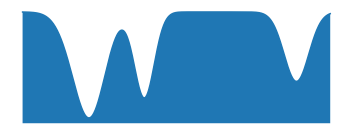

In [70]:
#fig = plt.figure(figsize=(5,2))
fig, ax = plt.subplots(figsize=(5,2))
ax.axis('off')
ax.plot(np.sum(Z,axis=0))
ax.fill_between(range(len(Z)), np.sum(Z,axis=0).squeeze(), ax.get_ylim()[0])
#ax.fill_between(np.sum(Z,axis=0),np.range(len(Z))-np.min(Z),) 
plt.tight_layout()
plt.savefig('Landscape_blue.pdf')
plt.show()

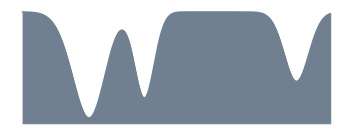

In [72]:
#fig = plt.figure(figsize=(5,2))
fig, ax = plt.subplots(figsize=(5,2))
ax.axis('off')
ax.plot(np.sum(Z,axis=0),c='slategray')
ax.fill_between(range(len(Z)), np.sum(Z,axis=0).squeeze(), ax.get_ylim()[0],color='slategray')
#ax.fill_between(np.sum(Z,axis=0),np.range(len(Z))-np.min(Z),) 
plt.tight_layout()
plt.savefig('Landscape.pdf', transparent=True)
plt.show()

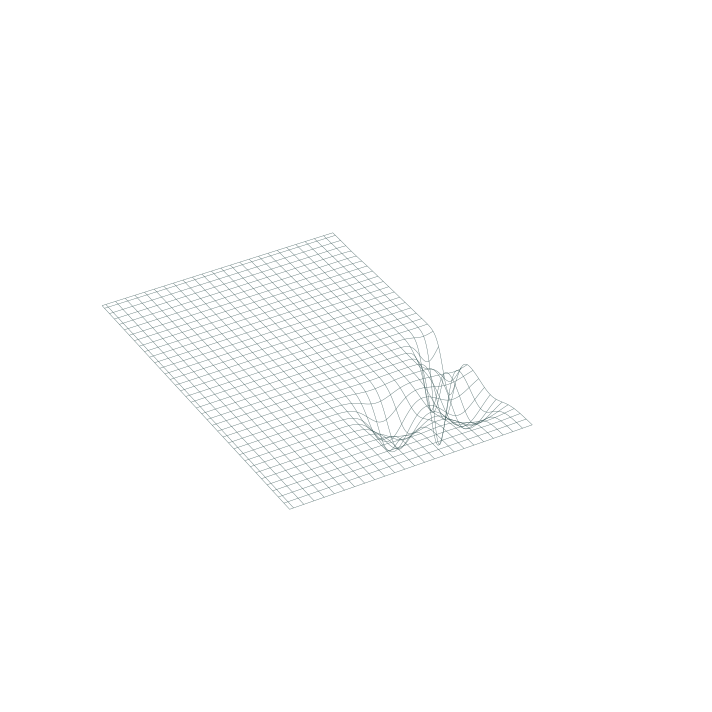

In [50]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib import cm

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d',aspect='auto')
cut=200
ax.plot_wireframe(X[cut:,:], Y[cut:,:], Z[cut:,:], rstride=18, cstride=18, alpha=0.9,colors='darkslategray',linewidth=0.35)
cset = ax.contour(X, Y, Z, zdir='z', offset=-0.5, cmap=cm.coolwarm,alpha=0.0)
#cset = ax.contour(X, Y, Z, zdir='x', offset=-40, cmap=cm.coolwarm)
#cset = ax.contour(X, Y, Z, zdir='y', offset=40, cmap=cm.coolwarm)
ax = plt.gca(projection='3d') 
ax._axis3don = False
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(-1, 1)
ax.view_init(35, 150)
plt.tight_layout()
plt.savefig('M2.pdf')
plt.show()

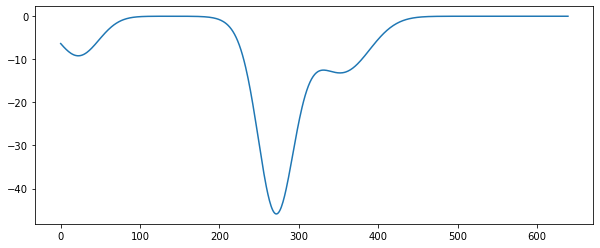

In [30]:
fig = plt.figure(figsize=(10,4))
plt.plot(np.sum(Z,axis=0))

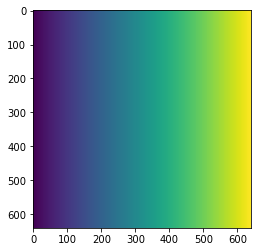

In [537]:
plt.imshow(X)

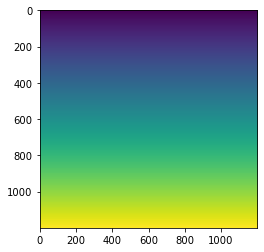

In [393]:
plt.imshow(Y)

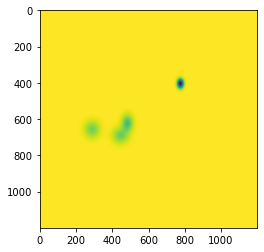

In [394]:
plt.imshow(Z)

In [55]:
def get_test_data(delta=0.025):

    x = y = np.arange(-8, 8, delta)
    X, Y = np.meshgrid(x, y)
    siz=int(16/delta)
    Z=np.zeros((siz,siz))
    
    for i in range(9):
        mu_x= 10*(np.random.rand()-np.random.rand())
        mu_y= 10*(np.random.rand()-np.random.rand())
        sig_x= 2.7-(i/7)#np.random.rand()
        sig_y= 1.6-(i/7) #np.random.rand()
        rv = stats.multivariate_normal([mu_x, mu_y],[sig_x, sig_y])
        Z -= rv.pdf(np.dstack((X, Y)))
    return X, Y, Z

In [68]:
xx,yy,zz = get_test_data(delta=0.5)


In [69]:
zz.shape

(32, 32)

In [76]:
flow=np.arange(-8,8,0.5)
bck=np.zeros((32,32))
for ii, i in enumerate(flow):
    for ij, j in enumerate(flow):
        bck[ii,ij]=0.25/((1+np.exp(-0.9*i-2.))*(1+np.exp(-1*j-5)))

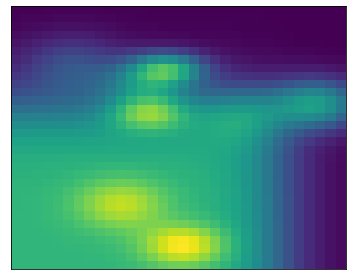

In [77]:
plt.figure(figsize=(5,4))
plt.imshow(bck[:,::-1]-zz,interpolation='none',aspect='auto')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [27]:
print(plt.rcParams['axes.prop_cycle'].by_key()['color'])

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


In [18]:
def get_test_data(delta=0.025):

    x = y = np.arange(-8, 8, delta)
    X, Y = np.meshgrid(x, y)
    siz=int(16/delta)
    Z=np.zeros((siz,siz))
    
    for i in range(4):
        mu_x= 10*(np.random.rand()-np.random.rand())
        mu_y= 10*(np.random.rand()-np.random.rand())
        sig_x= 0.7-(i/7)#np.random.rand()
        sig_y= 0.6-(i/7) #np.random.rand()
        rv = stats.multivariate_normal([mu_x, mu_y],[sig_x, sig_y])
        Z -= rv.pdf(np.dstack((X, Y)))
    return X, Y, Z

In [19]:
def get_test_data(delta=0.025):

    x = y = np.arange(-8, 8, delta)
    X, Y = np.meshgrid(x, y)
    siz=int(16/delta)
    Z=np.zeros((siz,siz))
    
    for i in range(6):
        mu_x= 10*(np.random.rand()-np.random.rand())
        mu_y= 10*(np.random.rand()-np.random.rand())
        sig_x= np.random.rand()
        sig_y= np.random.rand()
        rv = stats.multivariate_normal([mu_x, mu_y],[sig_x, sig_y])
        Z -= rv.pdf(np.dstack((X, Y)))
    return X, Y, Z

In [20]:
X, Y, Z = get_test_data(delta=0.01)


In [22]:
cut=200

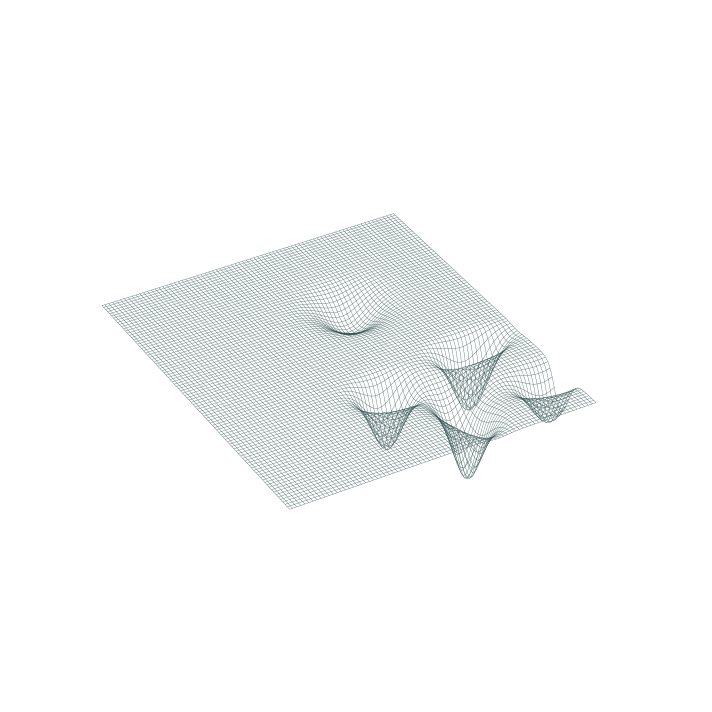

In [23]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib import cm

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d',aspect='auto')
#cut=200
ax.plot_wireframe(X[cut:,:], Y[cut:,:], Z[cut:,:], rstride=18, cstride=18, alpha=0.9,colors='darkslategray',linewidth=0.35)
cset = ax.contour(X, Y, Z, zdir='z', offset=-0.5, cmap=cm.coolwarm,alpha=0.0)
#cset = ax.contour(X, Y, Z, zdir='x', offset=-40, cmap=cm.coolwarm)
#cset = ax.contour(X, Y, Z, zdir='y', offset=40, cmap=cm.coolwarm)
ax = plt.gca(projection='3d') 
ax._axis3don = False
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(-1, 1)
ax.view_init(35, 150)
plt.tight_layout()
#plt.savefig('M2.pdf')
plt.show()

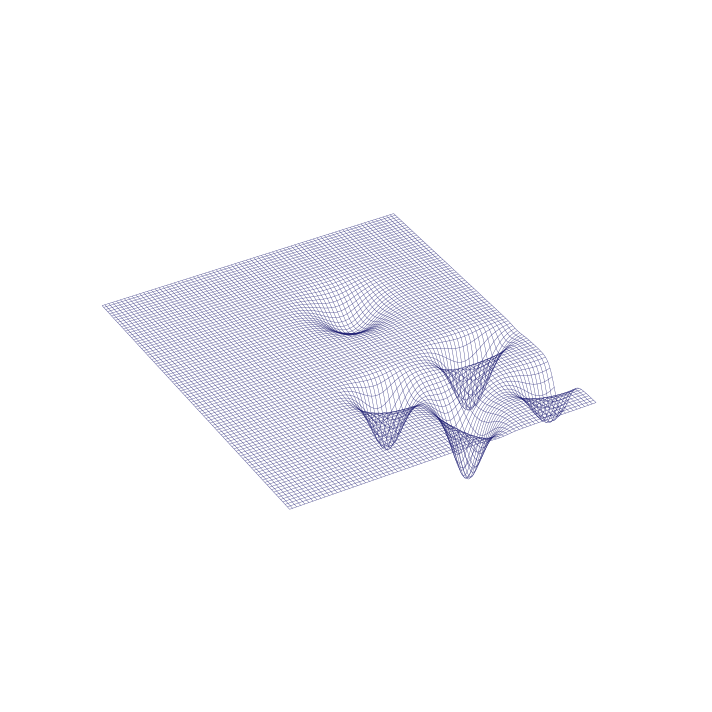

In [24]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib import cm

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d',aspect='auto')
#cut=200
ax.plot_wireframe(X[cut:,:], Y[cut:,:], Z[cut:,:], rstride=18, cstride=18, alpha=0.9,colors='midnightblue',linewidth=0.35)
cset = ax.contour(X, Y, Z, zdir='z', offset=-0.5, cmap=cm.coolwarm,alpha=0.0)
#cset = ax.contour(X, Y, Z, zdir='x', offset=-40, cmap=cm.coolwarm)
#cset = ax.contour(X, Y, Z, zdir='y', offset=40, cmap=cm.coolwarm)
ax = plt.gca(projection='3d') 
ax._axis3don = False
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(-1, 1)
ax.view_init(35, 150)
plt.tight_layout()
#plt.savefig('M2.pdf')
plt.show()

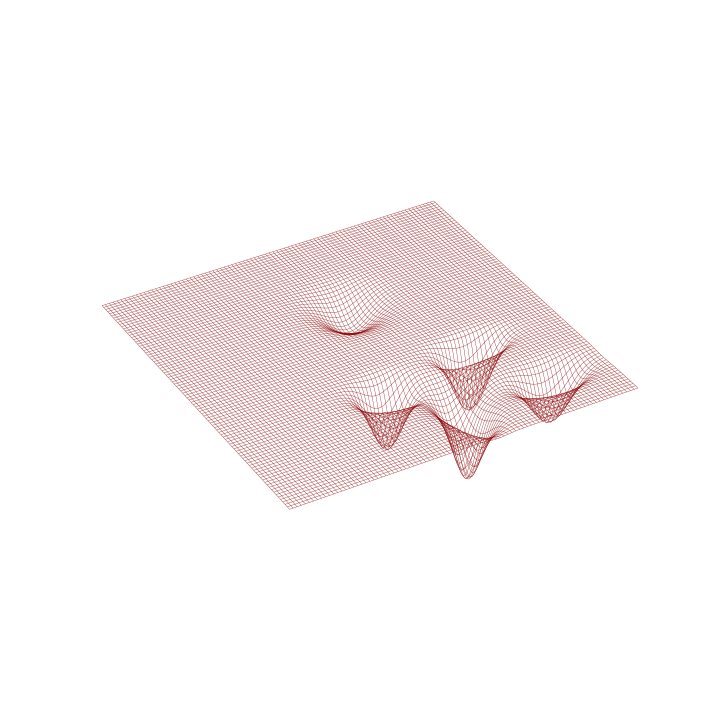

In [26]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib import cm

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d',aspect='auto')
cut=0#200
ax.plot_wireframe(X[cut:,:], Y[cut:,:], Z[cut:,:], rstride=18, cstride=18, alpha=0.9,colors='darkred',linewidth=0.35)
cset = ax.contour(X, Y, Z, zdir='z', offset=-0.5, cmap=cm.coolwarm,alpha=0.0)
#cset = ax.contour(X, Y, Z, zdir='x', offset=-40, cmap=cm.coolwarm)
#cset = ax.contour(X, Y, Z, zdir='y', offset=40, cmap=cm.coolwarm)
ax = plt.gca(projection='3d') 
ax._axis3don = False
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(-1, 1)
ax.view_init(35, 150)
plt.tight_layout()
#plt.savefig('M2.pdf')
plt.show()